<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [2]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 155.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 184.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 145.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 109.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 121.0 MB/s eta 0:00:00


Import pandas module


In [3]:
import pandas as pd


Import matplotlib


In [4]:
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [5]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [ ]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [6]:
## Count the number of duplicate rows in the dataset
duplicaterows = df.duplicated()
print ("No. of duplicate rows: ", duplicaterows.sum())

## Display the first few duplicate rows to understand their structure
duplicate_rows = df[df.duplicated()] #View duplicate rows (excluding first occurrence)
duplicate_rows.head()

No. of duplicate rows:  20


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
65439,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65440,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
65441,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [7]:
## Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
columns = ['MainBranch', 'Employment', 'RemoteWork']
a = df[df.duplicated(subset=columns)] #Check duplicates based on specific columns
a

## group rows that have the same responses in the mainbranch, employment and remote work together
grouped = df.groupby(columns)

# check if the other columns are the same for these responses
b = grouped.nunique() #returns how many unique values for other columns
b
# Other columns frequently sharing identical values within these response-pattern groups: Check, SurveyLength, SurveyEase
# Other columns with unique values: LearnCodeOnline, ConvertedCompYearly

ResponseId  \
MainBranch                                         Employment                                         RemoteWork                                         
I am a developer by profession                     Employed, full-time                                Hybrid (some remote, some in-person)       15286   
                                                                                                      In-person                                   7118   
                                                                                                      Remote                                     12191   
                                                   Employed, full-time;Employed, part-time            Hybrid (some remote, some in-person)          78   
                                                                                                      In-person                                     25   
...                                                                                                                                                ...   
I used to be a developer by profession, but no ... Student, full-time;Employed, part-time             Remote                                         2   
                                                   Student, full-time;Independent contractor, free... Hybrid (some remote, some in-person)           1   
                                                                                                      Remote                                         1   
                                                   Student, full-time;Not employed, but looking fo... Remote                                         1   
                                                   Student, part-time;Employed, part-time             Hybrid (some remote, some in-person)           2   

                                                                                                                                            Age  \
MainBranch                                         Employment                                         RemoteWork                                  
I am a developer by profession                     Employed, full-time                                Hybrid (some remote, some in-person)    8   
                                                                                                      In-person                               8   
                                                                                                      Remote                                  8   
                                                   Employed, full-time;Employed, part-time            Hybrid (some remote, some in-person)    5   
                                                                                                      In-person                               2   
...                                                                                                                                         ...   
I used to be a developer by profession, but no ... Student, full-time;Employed, part-time             Remote                                  2   
                                                   Student, full-time;Independent contractor, free... Hybrid (some remote, some in-person)    1   
                                                                                                      Remote                                  1   
                                                   Student, full-time;Not employed, but looking fo... Remote                                  1   
                                                   Student, part-time;Employed, part-time             Hybrid (some remote, some in-person)    1   

                                                                                                                                            Check  \
MainBranch                                         Employment               

### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


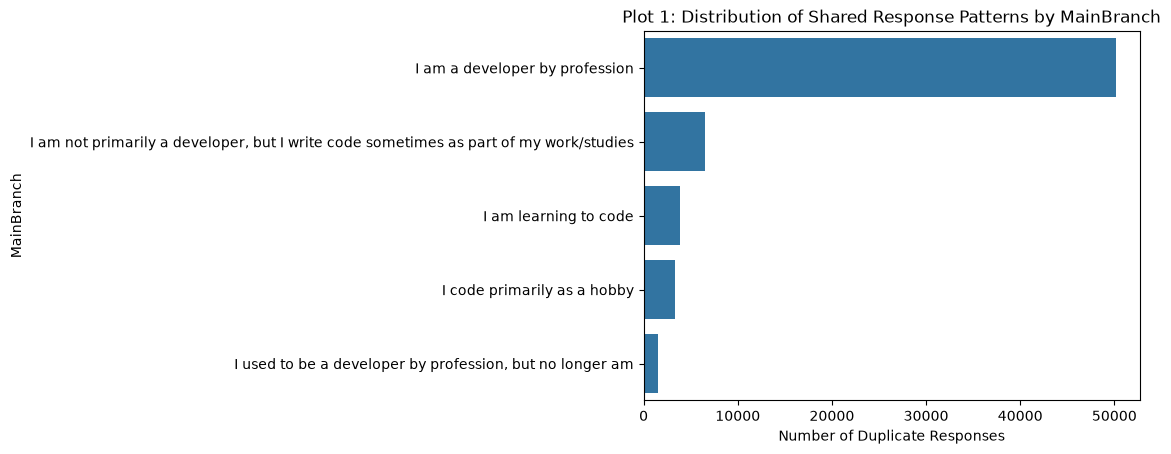

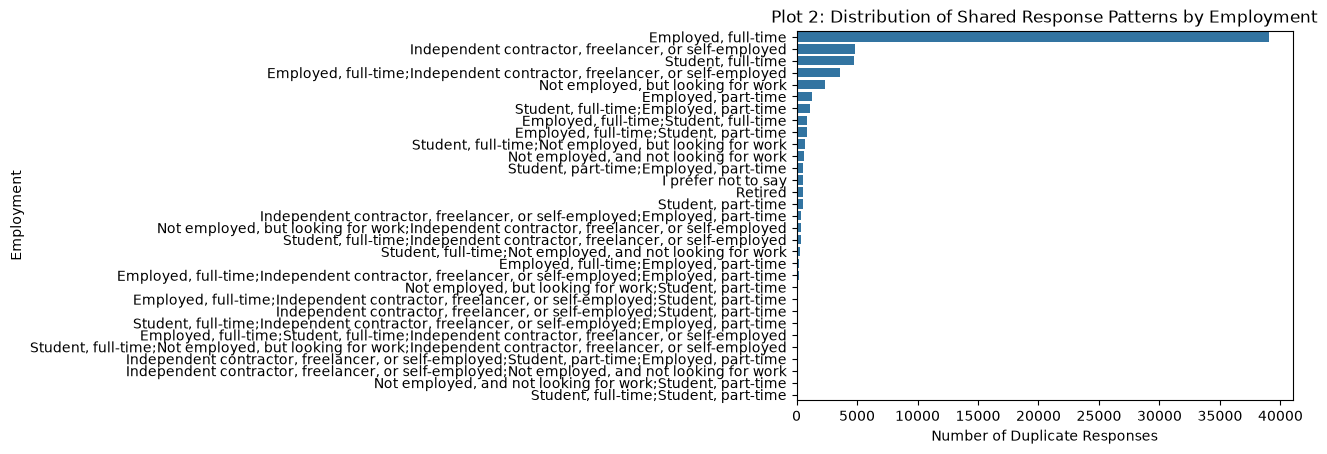

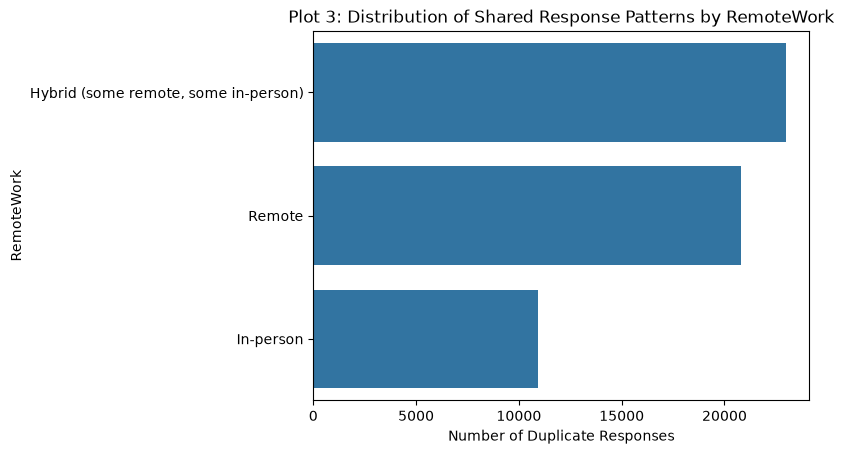

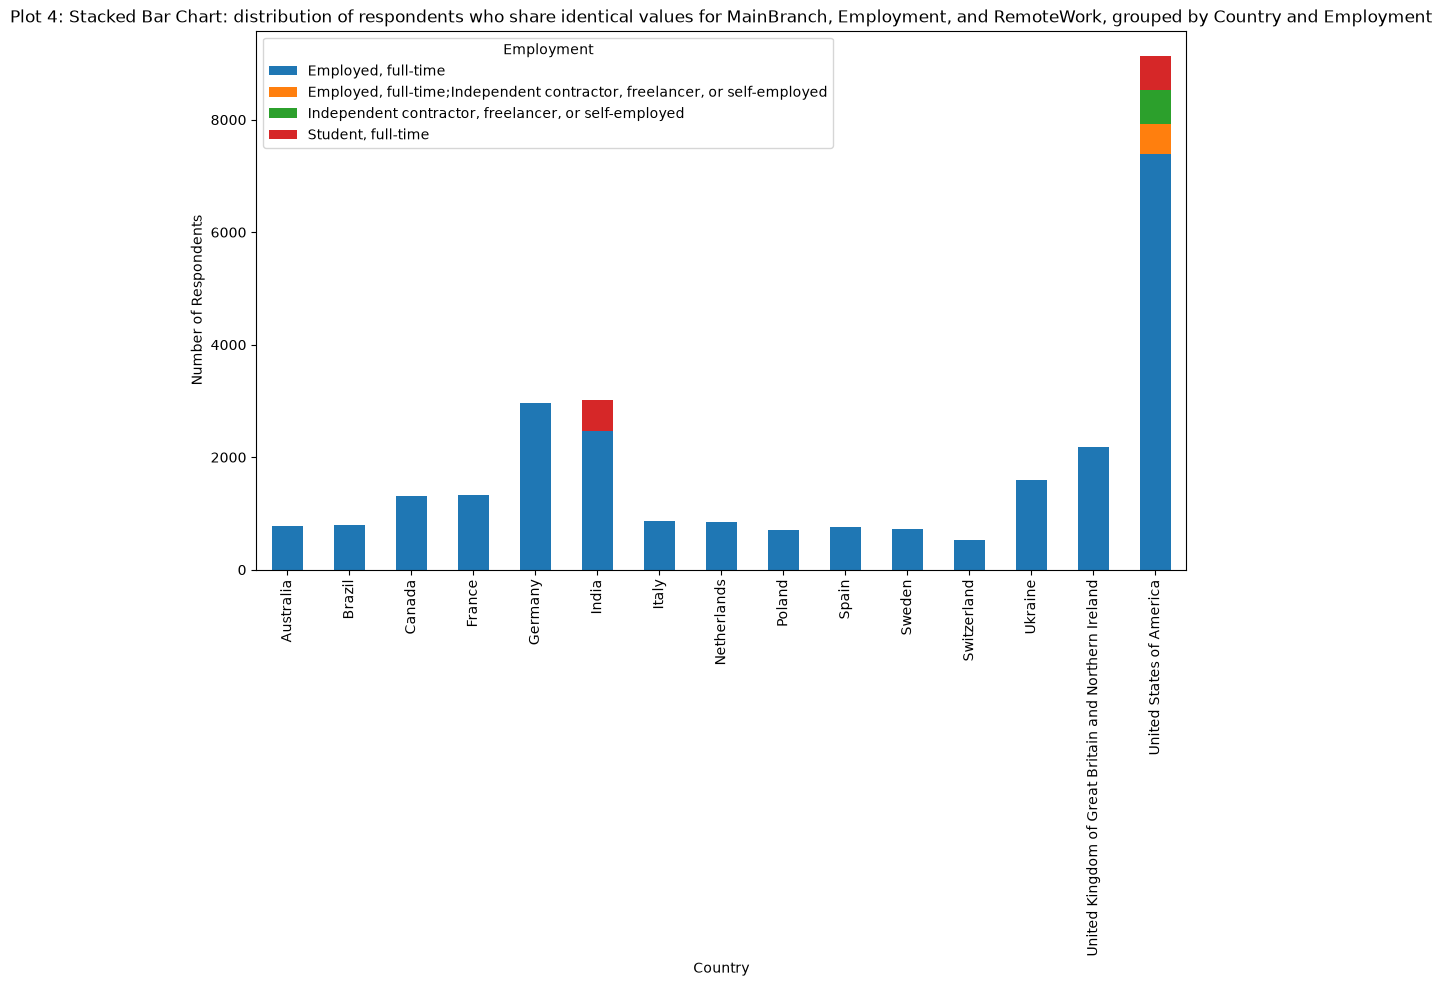

In [42]:
## Write your code here
import seaborn as sns

duplicates = df[df.duplicated(subset=columns, keep=False)]

# Count number of duplicates for 'MainBranch'
mainbranchdupcount = duplicates['MainBranch'].value_counts().reset_index()
mainbranchdupcount.columns = ['MainBranch', 'Count']

# Plot bar chart. Plot 1 for MainBranch
sns.barplot(data=mainbranchdupcount, x='Count', y='MainBranch', orient='h')
plt.title('Plot 1: Distribution of Shared Response Patterns by MainBranch')
plt.ylabel('MainBranch')
plt.xlabel('Number of Duplicate Responses')
plt.show()

# Plot 2 for Employment
## add Count as new column into duplicates dataframe after using value_counts()
duplicates["Empcount"] = duplicates["Employment"].map(duplicates["Employment"].value_counts())
## remove duplicates with count < = 50
emp = duplicates[duplicates["Empcount"] > 50]["Employment"]
## filter duplicates employment category to find the same employment categories in emp dataframe
filteredemp = duplicates[duplicates['Employment'].isin(emp)]['Employment']
filtered = filteredemp.value_counts().reset_index()
filtered.columns = ["Employment", "Count"]
sns.barplot(data=filtered, x='Count', y='Employment', orient='h')
plt.title('Plot 2: Distribution of Shared Response Patterns by Employment')
plt.ylabel('Employment')
plt.xlabel('Number of Duplicate Responses')
plt.show()

# Plot 3 for RemoteWork
rwcount = duplicates['RemoteWork'].value_counts().reset_index()
rwcount.columns = ['RemoteWork', 'Count']
sns.barplot(data=rwcount, x='Count', y='RemoteWork', orient='h')
plt.title('Plot 3: Distribution of Shared Response Patterns by RemoteWork')
plt.ylabel('RemoteWork')
plt.xlabel('Number of Duplicate Responses')
plt.show()

#Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.
a = duplicates.groupby(["Country", "Employment"]).size().reset_index(name='Count')
# Only include counts > 500
b = a[a['Count'] > 500][['Employment','Country', 'Count']]
# Reshape into a wide format table
pivotdata = b.pivot(index='Country', columns='Employment', values='Count').fillna(0)
# Plot the reshaped DataFrame
pivotdata.plot(kind='bar', stacked=True, figsize=(12,7))
plt.title('Plot 4: Stacked Bar Chart: distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment')
plt.ylabel('Number of Respondents')
plt.xlabel('Country')
plt.legend(title='Employment')
plt.show()


### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
